<a href="https://colab.research.google.com/github/natrask/ENM5320-2026/blob/main/NewMaterial/Lecture12_Feb26/FEMconvergence_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Finite Element Method (FEM) Demo: 1D Poisson Equation

## Overview

This notebook walks through a complete implementation of the **finite element method** (FEM) for solving the 1D Poisson equation:

$$-u''(x) = f(x), \quad x \in [0,1]$$

with a **Dirichlet** boundary condition on the left ($u(0) = 0$) and a **Neumann** boundary condition on the right ($u'(1) = 0$).

We choose $f(x) = 1$, which gives the exact solution $u(x) = x(1 - x/2)$.

### What you will learn
1. How to define a finite element mesh and basis functions (hat functions)
2. How to evaluate basis functions and their gradients
3. How to build the stiffness matrix using Gauss-Legendre quadrature
4. How to impose Dirichlet and Neumann boundary conditions
5. How to solve the resulting linear system
6. How to verify convergence rates predicted by FEM theory

---
## Step 0: Imports and Setup

We use **PyTorch** for tensor operations (and GPU support), along with standard scientific Python libraries for plotting.

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import torch

import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import torch.utils.data as data
import torchvision.transforms as transforms
import torchvision.datasets as datasets

# Set random seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

# Check if CUDA is available and set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")

Using device: cuda


---
## Step 1: Build the Finite Element Mesh

A finite element mesh is a partition of the domain $[0,1]$ into smaller intervals (elements). We place `meshsize` equally-spaced **nodes** $x_0, x_1, \ldots, x_{N-1}$ at positions $x_i = ih$ where $h = 1/(N-1)$ is the **mesh spacing**.

The element between nodes $x_i$ and $x_{i+1}$ is denoted $[x_i, x_{i+1}]$.

We also create a fine grid (`finepoints`) for plotting smooth curves.

In [2]:
# Number of nodes in the mesh (try changing this: 4, 8, 16, 32)
meshsize = 8
h = 1.0 / float(meshsize - 1)  # element size
points = torch.tensor(np.linspace(0, 1, meshsize), dtype=torch.float64)
finepoints = torch.tensor(np.linspace(0, 1, 21 * meshsize), dtype=torch.float64)

print(f"Number of nodes: {meshsize}")
print(f"Mesh spacing h = {h:.4f}")
print(f"Node positions: {points.numpy()}")

Number of nodes: 8
Mesh spacing h = 0.1429
Node positions: [0.         0.14285714 0.28571429 0.42857143 0.57142857 0.71428571
 0.85714286 1.        ]


---
## Step 2: Define Basis Functions (Hat Functions)

In the standard 1D FEM with piecewise-linear elements, the **basis function** $\phi_i(x)$ associated with node $x_i$ is a "hat function":

$$\phi_i(x) = \max\!\left(0,\; 1 - \frac{|x - x_i|}{h}\right)$$

Key properties:
- $\phi_i(x_i) = 1$ (equals 1 at its own node)
- $\phi_i(x_j) = 0$ for $j \neq i$ (equals 0 at all other nodes)
- $\phi_i(x)$ is nonzero only on $[x_{i-1}, x_{i+1}]$ (compact support)
- The $\phi_i$ form a **partition of unity**: $\sum_i \phi_i(x) = 1$

The FEM approximate solution is written as:
$$u_h(x) = \sum_{i=0}^{N-1} u_i \, \phi_i(x)$$
where the $u_i$ are the unknown nodal coefficients we need to solve for.

### Gradient of basis functions

The derivative of a hat function is piecewise constant:
$$\phi_i'(x) = \begin{cases} +1/h & \text{if } x \in [x_{i-1}, x_i] \\ -1/h & \text{if } x \in [x_i, x_{i+1}] \\ 0 & \text{otherwise} \end{cases}$$

Below we implement `evalPhi_i(x)` and `evalGradPhi_i(x)`, which evaluate **all** basis functions (and their gradients) at a batch of points simultaneously.

In [3]:
def evalPhi_i(x):
    """
    Evaluate all N hat functions at a set of query points x.
    
    Args:
        x: tensor of shape (Q,) -- Q query points
    Returns:
        tensor of shape (N, Q) -- phi_i(x_q) for each basis i and query point q
    """
    x_expanded = torch.unsqueeze(x, 0)          # shape (1, Q)
    points_expanded = torch.unsqueeze(points, 1) # shape (N, 1)
    # ReLU clips negative values to 0, giving the hat shape
    return torch.relu(1.0 - (torch.abs(x_expanded - points_expanded)) / h)


def evalGradPhi_i(x):
    """
    Evaluate the gradient of all N hat functions at query points x.
    
    Args:
        x: tensor of shape (Q,)
    Returns:
        tensor of shape (N, Q) -- phi_i'(x_q)
    """
    # Mask: nonzero only where phi_i(x) > 0 (inside support)
    suppPhi = (evalPhi_i(x) > 0).double()
    # Sign: +1/h on the left side of the hat, -1/h on the right
    signPlus = (torch.unsqueeze(points, 1) > torch.unsqueeze(x, 0)).double()
    signNeg = (torch.unsqueeze(points, 1) <= torch.unsqueeze(x, 0)).double()
    return suppPhi * (-signPlus + signNeg) / h

### Visualize the basis functions

Let's plot $\phi_i(x)$ and $\phi_i'(x)$ over the fine grid. You should see overlapping "hats" that tile the domain, and piecewise-constant derivatives.

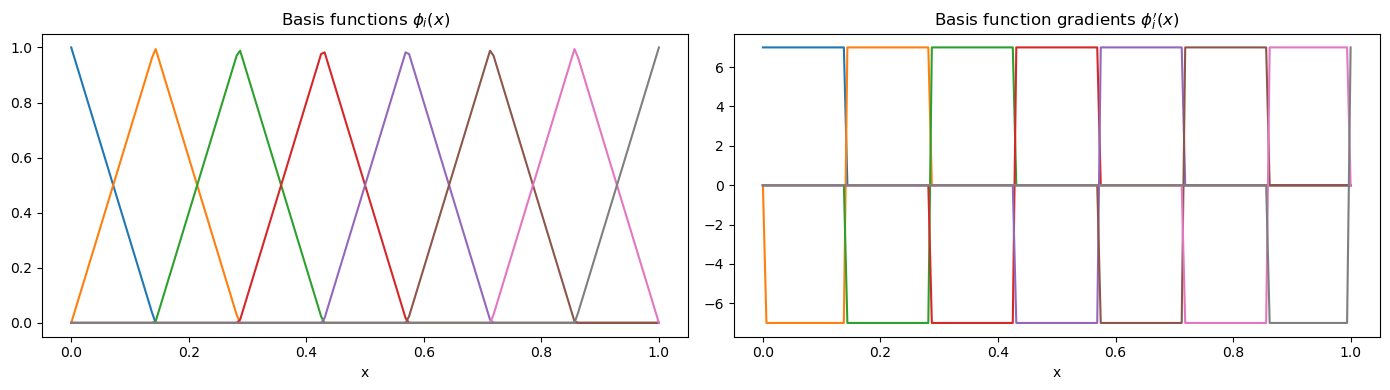

In [4]:
phi_i = evalPhi_i(finepoints)
grad_phi_i = evalGradPhi_i(finepoints)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].plot(finepoints.numpy(), phi_i.numpy().T)
axes[0].set_title(r"Basis functions $\phi_i(x)$")
axes[0].set_xlabel("x")

axes[1].plot(finepoints.numpy(), grad_phi_i.numpy().T)
axes[1].set_title(r"Basis function gradients $\phi_i'(x)$")
axes[1].set_xlabel("x")

plt.tight_layout()
plt.show()

---
## Step 3: Construct the Stiffness Matrix via Numerical Quadrature

### The Weak Form

We don't solve $-u'' = f$ directly (the **strong form**). Instead, we multiply by a test function $v(x)$ and integrate by parts to get the **weak form**:

$$\int_0^1 u'(x) \, v'(x) \, dx = \int_0^1 f(x) \, v(x) \, dx + [u'(x) v(x)]_0^1$$

The boundary term $[u'v]_0^1$ handles the Neumann condition. Since $v(0) = 0$ (test functions vanish where Dirichlet BCs are imposed) and $u'(1) = 0$ (Neumann BC), this term vanishes.

### The Stiffness Matrix

Substituting $u_h = \sum_j u_j \phi_j$ and choosing $v = \phi_i$, the weak form becomes the linear system:

$$\sum_j S_{ij} \, u_j = F_i$$

where the **stiffness matrix** is:
$$S_{ij} = \int_0^1 \phi_i'(x) \, \phi_j'(x) \, dx$$

and the **load vector** is:
$$F_i = \int_0^1 f(x) \, \phi_i(x) \, dx$$

### Gauss-Legendre Quadrature

We approximate integrals numerically using **Gauss-Legendre quadrature**. On each element $[x_k, x_{k+1}]$ of length $h$, we use two quadrature points:

$$x_q^{\pm} = x_k + \frac{h}{2} \pm \frac{h}{2\sqrt{3}}$$

with equal weights $w = h/2$ each. Two-point Gaussian quadrature exactly integrates polynomials up to degree 3, which is sufficient for our piecewise-linear basis functions (whose products are at most piecewise-quadratic).

In [5]:
# Compute the 2-point Gauss-Legendre quadrature points on each element
# Points are at center +/- h/(2*sqrt(3)) within each element
xql = points[:-1].numpy() + h * (0.5 + 1.0 / (2.0 * np.sqrt(3)))
xqr = points[:-1].numpy() + h * (0.5 - 1.0 / (2.0 * np.sqrt(3)))
xq = np.concatenate([xql, xqr])
xq = np.sort(xq)
xq = torch.tensor(xq, dtype=torch.float64)

print(f"Number of quadrature points: {len(xq)}")
print(f"Quadrature points: {xq.numpy().round(4)}")

Number of quadrature points: 14
Quadrature points: [0.0302 0.1127 0.173  0.2555 0.3159 0.3984 0.4588 0.5412 0.6016 0.6841
 0.7445 0.827  0.8873 0.9698]


### Assembling the Stiffness Matrix

We evaluate all basis function gradients at the quadrature points, then compute:

$$S_{ij} \approx \frac{h}{2} \sum_{q} \phi_i'(x_q) \, \phi_j'(x_q)$$

The `torch.einsum` call performs this summation efficiently over all quadrature points.

The resulting matrix $S$ is:
- **Symmetric**: $S_{ij} = S_{ji}$ (since $\phi_i' \phi_j' = \phi_j' \phi_i'$)
- **Sparse/banded**: $S_{ij} = 0$ whenever nodes $i$ and $j$ are more than one element apart
- **Positive semi-definite**: it has a one-dimensional null space (constant functions)

In [6]:
# Evaluate basis functions and gradients at quadrature points
nodal_basisEval = evalPhi_i(xq)        # shape (N, Q)
nodal_gradbasisEval = evalGradPhi_i(xq) # shape (N, Q)

# Stiffness matrix: S_ij = (h/2) * sum_q  phi_i'(x_q) * phi_j'(x_q)
Snodal = (h / 2) * torch.einsum(
    'ijq->ij',
    torch.unsqueeze(nodal_gradbasisEval, 0) * torch.unsqueeze(nodal_gradbasisEval, 1)
)

print(f"Stiffness matrix shape: {Snodal.shape}")
print(f"Stiffness matrix (rounded):\n{Snodal.numpy().round(4)}")

Stiffness matrix shape: torch.Size([8, 8])
Stiffness matrix (rounded):
[[ 7. -7.  0.  0.  0.  0.  0.  0.]
 [-7. 14. -7.  0.  0.  0.  0.  0.]
 [ 0. -7. 14. -7.  0.  0.  0.  0.]
 [ 0.  0. -7. 14. -7.  0.  0.  0.]
 [ 0.  0.  0. -7. 14. -7.  0.  0.]
 [ 0.  0.  0.  0. -7. 14. -7.  0.]
 [ 0.  0.  0.  0.  0. -7. 14. -7.]
 [ 0.  0.  0.  0.  0.  0. -7.  7.]]


---
## Step 4: Assemble the Load Vector and Apply Boundary Conditions

### Load vector

For our constant forcing $f(x) = 1$, the load vector is:
$$F_i = \int_0^1 \phi_i(x) \, dx \approx \frac{h}{2} \sum_q \phi_i(x_q)$$

### Applying boundary conditions

**Dirichlet BC** ($u(0) = 0$): We replace the first equation (row 0 of the system) with the constraint $u_0 = 0$. This is done by setting row 0 of the matrix to $[1, 0, 0, \ldots]$ and the right-hand side to $u_D = 0$.

**Neumann BC** ($u'(1) = 0$): This is a *natural* boundary condition — it is automatically satisfied by the weak form and requires no special treatment in the matrix assembly. The boundary integral term vanishes because $u'(1) = 0$.

In [7]:
# Forcing: f(x) = 1 everywhere
forcingvec = torch.ones(meshsize, dtype=torch.float64)

# Load vector: F_i = (h/2) * sum_q f(x_q) * phi_i(x_q)
# Since f=1, this simplifies to (h/2) * sum_q phi_i(x_q)
forcing = (h / 2) * torch.einsum('i,iq->i', forcingvec, nodal_basisEval)

print(f"Load vector: {forcing.numpy().round(6)}")

# Dirichlet value at x=0
uLHS = 0.0

# Build the right-hand side: replace first entry with Dirichlet value
solution_rhs = torch.cat(
    [torch.tensor([uLHS], dtype=torch.float64), forcing[1:meshsize]], dim=0
)

# Build the system matrix: replace first row with [1, 0, 0, ...] for Dirichlet BC
solution_mat = torch.cat([
    torch.unsqueeze(
        torch.nn.functional.one_hot(torch.tensor(0), meshsize).double(), 0
    ),
    Snodal[1:meshsize, :]
], dim=0)

print(f"\nSystem matrix (with Dirichlet BC applied):\n{solution_mat.numpy().round(4)}")
print(f"\nRHS vector: {solution_rhs.numpy().round(6)}")

Load vector: [0.071429 0.142857 0.142857 0.142857 0.142857 0.142857 0.142857 0.071429]

System matrix (with Dirichlet BC applied):
[[ 1.  0.  0.  0.  0.  0.  0.  0.]
 [-7. 14. -7.  0.  0.  0.  0.  0.]
 [ 0. -7. 14. -7.  0.  0.  0.  0.]
 [ 0.  0. -7. 14. -7.  0.  0.  0.]
 [ 0.  0.  0. -7. 14. -7.  0.  0.]
 [ 0.  0.  0.  0. -7. 14. -7.  0.]
 [ 0.  0.  0.  0.  0. -7. 14. -7.]
 [ 0.  0.  0.  0.  0.  0. -7.  7.]]

RHS vector: [0.       0.142857 0.142857 0.142857 0.142857 0.142857 0.142857 0.071429]


---
## Step 5: Solve the Linear System

We now solve $A \mathbf{u} = \mathbf{b}$ for the nodal coefficients $\mathbf{u} = [u_0, u_1, \ldots, u_{N-1}]$.

The exact solution to our problem is:
$$u(x) = x\left(1 - \frac{x}{2}\right), \qquad u'(x) = 1 - x$$

We plot both the FEM solution and the exact solution to verify correctness.

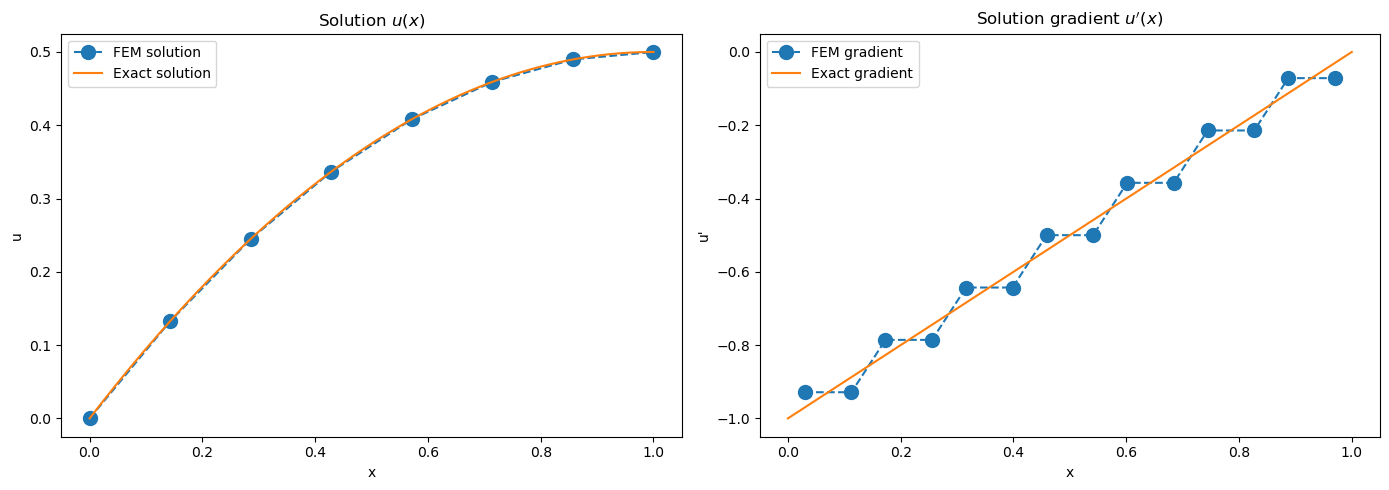

In [8]:
# Solve the linear system
u_sol = torch.linalg.solve(solution_mat, solution_rhs)

# Exact solution for comparison
uexact = finepoints.numpy() * (-0.5 * finepoints.numpy() + 1.0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot solution
axes[0].plot(points.numpy(), u_sol.numpy(), '.--', label='FEM solution', markersize=20)
axes[0].plot(finepoints.numpy(), uexact, label='Exact solution')
axes[0].legend()
axes[0].set_title("Solution $u(x)$")
axes[0].set_xlabel("x")
axes[0].set_ylabel("u")

# Plot derivative of solution on quadrature points
u_sol_grad = torch.matmul(evalGradPhi_i(xq).T, u_sol)
uexact_grad = -1 + finepoints.numpy()
axes[1].plot(xq.numpy(), u_sol_grad.numpy(), '.--', label='FEM gradient', markersize=20)
axes[1].plot(finepoints.numpy(), uexact_grad, label='Exact gradient')
axes[1].legend()
axes[1].set_title("Solution gradient $u'(x)$")
axes[1].set_xlabel("x")
axes[1].set_ylabel("u'")

plt.tight_layout()
plt.show()

---
## Step 6: Convergence Analysis

### What FEM theory predicts

For piecewise-linear finite elements on a mesh of size $h$, the **a priori error estimates** (from Céa's lemma and interpolation theory) give:

| Norm | Error bound | Convergence rate |
|------|------------|------------------|
| $L^2$ norm: $\|u - u_h\|_{L^2}$ | $\leq C h^2 \|f\|$ | $O(h^2)$ |
| Energy norm: $\|u - u_h\|_E = \|u' - u_h'\|_{L^2}$ | $\leq C h \|f\|$ | $O(h)$ |

The $L^2$ error bound comes from the **Aubin-Nitsche duality argument**, which gains an extra power of $h$ beyond the energy norm estimate.

### Computing the error

We compute both norms numerically using quadrature:
$$\|u - u_h\|_{L^2} \approx \sqrt{\frac{h}{2} \sum_q (u(x_q) - u_h(x_q))^2}$$
$$\|u' - u_h'\|_{L^2} \approx \sqrt{\frac{h}{2} \sum_q (u'(x_q) - u_h'(x_q))^2}$$

In [9]:
# Evaluate exact solution and its derivative at quadrature points
uex_q = xq.numpy() * (-0.5 * xq.numpy() + 1.0)
uex_qprime = -1.0 + xq.numpy()

# Evaluate FEM solution and its derivative at quadrature points
uq = torch.matmul(nodal_basisEval.T, u_sol)
uqprime = torch.matmul(nodal_gradbasisEval.T, u_sol)

# Compute L2 error in u
L2error = np.sqrt(h * torch.sum((uq - uex_q) ** 2).item())
# Compute L2 error in u' (energy semi-norm)
L2errorprime = np.sqrt(h * torch.sum((uqprime - uex_qprime) ** 2).item())

print(f"Mesh spacing h = {h:.6f}")
print(f"L2 error  ||u - u_h||   = {L2error:.10e}")
print(f"H1 error  ||u' - u_h'|| = {L2errorprime:.10e}")

Mesh spacing h = 0.142857
L2 error  ||u - u_h||   = 2.4051251061e-03
H1 error  ||u' - u_h'|| = 5.8321184352e-02


---
## Step 7: Verify Convergence Rates

To verify the predicted convergence rates, we run the entire FEM solve for several mesh sizes and examine how the errors decrease as $h \to 0$. 

If we plot $\log(\text{error})$ vs. $\log(h)$, the slope gives the convergence rate. We expect:
- **Slope $\approx 2$** for the $L^2$ error
- **Slope $\approx 1$** for the energy (H1) error

In [10]:
def fem_solve(N):
    """Run the full FEM pipeline for a mesh with N nodes. Returns (h, L2_error, H1_error)."""
    h_loc = 1.0 / float(N - 1)
    pts = torch.tensor(np.linspace(0, 1, N), dtype=torch.float64)

    def phi(x):
        return torch.relu(1.0 - torch.abs(x.unsqueeze(0) - pts.unsqueeze(1)) / h_loc)

    def grad_phi(x):
        sp = (phi(x) > 0).double()
        sP = (pts.unsqueeze(1) > x.unsqueeze(0)).double()
        sN = (pts.unsqueeze(1) <= x.unsqueeze(0)).double()
        return sp * (-sP + sN) / h_loc

    # Quadrature points
    xql_ = pts[:-1].numpy() + h_loc * (0.5 + 1.0 / (2.0 * np.sqrt(3)))
    xqr_ = pts[:-1].numpy() + h_loc * (0.5 - 1.0 / (2.0 * np.sqrt(3)))
    xq_ = torch.tensor(np.sort(np.concatenate([xql_, xqr_])), dtype=torch.float64)

    bEval = phi(xq_)
    gbEval = grad_phi(xq_)

    S = (h_loc / 2) * torch.einsum('ijq->ij',
        torch.unsqueeze(gbEval, 0) * torch.unsqueeze(gbEval, 1))

    fvec = torch.ones(N, dtype=torch.float64)
    F = (h_loc / 2) * torch.einsum('i,iq->i', fvec, bEval)

    rhs = torch.cat([torch.tensor([0.0], dtype=torch.float64), F[1:N]])
    mat = torch.cat([
        torch.nn.functional.one_hot(torch.tensor(0), N).double().unsqueeze(0),
        S[1:N, :]
    ])

    u = torch.linalg.solve(mat, rhs)

    # Errors at quadrature points
    ue = xq_.numpy() * (-0.5 * xq_.numpy() + 1.0)
    uep = -1.0 + xq_.numpy()
    uh = torch.matmul(bEval.T, u)
    uhp = torch.matmul(gbEval.T, u)

    l2 = np.sqrt(h_loc * torch.sum((uh - ue) ** 2).item())
    h1 = np.sqrt(h_loc * torch.sum((uhp - uep) ** 2).item())
    return h_loc, l2, h1


# Run for several mesh sizes
mesh_sizes = [4, 8, 16, 32, 64]
results = [fem_solve(N) for N in mesh_sizes]

hs = [r[0] for r in results]
l2_errors = [r[1] for r in results]
h1_errors = [r[2] for r in results]

# Print results table
print(f"{'N':>5}  {'h':>12}  {'L2 error':>14}  {'H1 error':>14}")
print("-" * 50)
for N, (hv, l2, h1) in zip(mesh_sizes, results):
    print(f"{N:5d}  {hv:12.6f}  {l2:14.8e}  {h1:14.8e}")

# Compute convergence rates
print("\nConvergence rates (between successive refinements):")
for i in range(1, len(hs)):
    rate_l2 = np.log(l2_errors[i-1] / l2_errors[i]) / np.log(hs[i-1] / hs[i])
    rate_h1 = np.log(h1_errors[i-1] / h1_errors[i]) / np.log(hs[i-1] / hs[i])
    print(f"  N={mesh_sizes[i-1]:3d} -> {mesh_sizes[i]:3d}:  L2 rate = {rate_l2:.2f},  H1 rate = {rate_h1:.2f}")

    N             h        L2 error        H1 error
--------------------------------------------------
    4      0.333333  1.30945700e-02  1.36082763e-01
    8      0.142857  2.40512511e-03  5.83211844e-02
   16      0.066667  5.23782801e-04  2.72165527e-02
   32      0.032258  1.22633850e-04  1.31692997e-02
   64      0.015873  2.96929025e-05  6.48013159e-03

Convergence rates (between successive refinements):
  N=  4 ->   8:  L2 rate = 2.00,  H1 rate = 1.00
  N=  8 ->  16:  L2 rate = 2.00,  H1 rate = 1.00
  N= 16 ->  32:  L2 rate = 2.00,  H1 rate = 1.00
  N= 32 ->  64:  L2 rate = 2.00,  H1 rate = 1.00


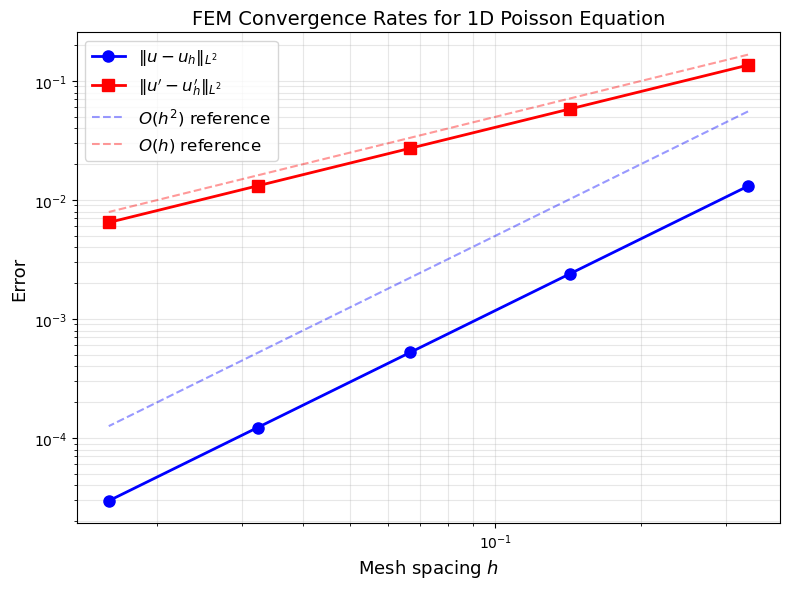

In [11]:
# Log-log convergence plot
fig, ax = plt.subplots(figsize=(8, 6))

ax.loglog(hs, l2_errors, 'bo-', linewidth=2, markersize=8, label=r'$\|u - u_h\|_{L^2}$')
ax.loglog(hs, h1_errors, 'rs-', linewidth=2, markersize=8, label=r"$\|u' - u_h'\|_{L^2}$")

# Reference slopes
h_ref = np.array(hs)
ax.loglog(h_ref, 0.5 * h_ref**2, 'b--', alpha=0.4, label=r'$O(h^2)$ reference')
ax.loglog(h_ref, 0.5 * h_ref**1, 'r--', alpha=0.4, label=r'$O(h)$ reference')

ax.set_xlabel('Mesh spacing $h$', fontsize=13)
ax.set_ylabel('Error', fontsize=13)
ax.set_title('FEM Convergence Rates for 1D Poisson Equation', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Summary

| Step | What we did | Key concept |
|------|------------|-------------|
| 1 | Defined a uniform mesh on $[0,1]$ | Mesh spacing $h$ controls accuracy |
| 2 | Built piecewise-linear hat functions $\phi_i$ | Basis functions with compact support |
| 3 | Assembled stiffness matrix $S_{ij} = \int \phi_i' \phi_j' dx$ | Gauss-Legendre quadrature |
| 4 | Built load vector and applied BCs | Dirichlet (essential) vs. Neumann (natural) |
| 5 | Solved $S\mathbf{u} = \mathbf{F}$ | Standard linear algebra |
| 6-7 | Measured errors and convergence rates | $O(h^2)$ in $L^2$, $O(h)$ in energy norm |

### Exercises
1. **Change the mesh size**: Try `meshsize = 4, 16, 32` and observe how the solution improves.
2. **Different forcing**: Change $f(x) = 1$ to $f(x) = \sin(\pi x)$ and derive the new exact solution.
3. **Different BCs**: Modify the code to impose Dirichlet conditions on both ends ($u(0) = 0, u(1) = 0$).
4. **Add noise to nodes**: Perturb the node locations slightly (e.g., `points += 0.1*h*torch.randn(...)`) and verify the theory still holds.